# Carrier-rate asymmetry diagnostic — is the +41% cactus h-bias real?

**Standalone diagnostic. Created 2026-05-13.**

The `FINAL_RESULTS_cov10_v3.ipynb` plots show two visible off-diagonal streaks on `cactus_em-v3 ★★` (10kb + λ=0.3 + smooth):

- **Below diagonal** (truth high → est low): predicted to be **PG-specific** variants (carrier_PG ≫ carrier_cactus) — the +41% cactus h-bias pulls predicted AF down.
- **Above diagonal** (truth low → est high): predicted to be **cactus-specific** variants — the bias pushes predicted AF up.

**The test**: color every variant by `log2(carrier_PG / carrier_cactus)`. If the mechanism is right:

- Above-diagonal points should be **blue** (cactus-specific, log2 < 0)
- Below-diagonal points should be **red** (PG-specific, log2 > 0)
- Main-diagonal cloud should be **gray** (balanced)

This notebook runs the diagnostic for **both** v3 cactus_em variants:

- `cactus_em-v3 global` — single chrom-wide h (less per-window noise, same bias)
- `cactus_em-v3 ★★` — per-window 10kb h with anchor+smooth (per-window noise on top of bias)

If both show the same blue/red streak pattern, the bias is structural to the h-vector itself (mechanism confirmed). If ★★ shows it but global doesn't, the issue is per-window-noise-specific.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

ROOT = Path('/global/scratch/users/tbellg/hapfire_sv')
SIMS = ROOT / 'sims/visor_freqk'

# Pick regime here. Default = n200_g1 (the one whose plot triggered this investigation).
# Other valid: 'n50_g1_cov10', 'n50_g3_cov10', 'n50_g3_skewed_cov10'.
REGIME = 'n200_g1_cov10'
REGIME_DIRS = {
    'n200_g1_cov10':       SIMS / 'pool_sweep_82_recomb'        / 'cov10_n200_g1_s42_hotspots_p231_chr1',
    'n50_g1_cov10':        SIMS / 'pool_sweep_82_recomb'        / 'cov10_n50_g1_s42_hotspots_p231_chr1',
    'n50_g3_cov10':        SIMS / 'pool_sweep_82_recomb'        / 'cov10_n50_g3_s42_hotspots_p231_chr1',
    'n50_g3_skewed_cov10': SIMS / 'pool_sweep_82_recomb_skewed' / 'cov10_n50_g3_s42_hotspots_dom500_p231_chr1',
}
WORK = REGIME_DIRS[REGIME]

# Two cactus_em-v3 variants to compare.
METHODS = {
    'global':  ('cactus_em-v3 global (chrom-wide h)',      'cactus_em_recomb_GLOBAL_v3.tsv'),
    'window':  ('cactus_em-v3 ★★ 10kb + λ=0.3 + smooth', 'cactus_em_recomb_window_10kb_anchor0.3_smooth5a05_v3.tsv'),
}
print(f'Regime: {REGIME}\nWorking directory: {WORK}')


Regime: n200_g1_cov10
Working directory: /global/scratch/users/tbellg/hapfire_sv/sims/visor_freqk/pool_sweep_82_recomb/cov10_n200_g1_s42_hotspots_p231_chr1


## 1. Compute per-variant carrier rates in the cactus vs PG founder groups

`carrier_rate_cactus` = fraction of the 80 long-read-assembly founders carrying ALT.

`carrier_rate_PG`     = fraction of the 151 PanGenie-genotyped founders carrying ALT.

`log2(PG/cactus)` is the asymmetry metric. A small pseudocount (1/231) keeps zeros finite.


In [2]:
# Founder split
with open(ROOT / 'data/founder_split_cactus_pg.json') as fh:
    _split = json.load(fh)
CACTUS_IDS, PG_IDS = set(_split['cactus']), set(_split['PG'])

# cn_var_v3 column order
META = np.load(ROOT / 'poolfreq/data/cn_var_231_v3.meta.npz', allow_pickle=True)
CN   = sp.load_npz(ROOT / 'poolfreq/data/cn_var_231_v3.cn_var.npz')
founders = list(META['founders'])
cactus_idx = np.array([i for i, f in enumerate(founders) if f in CACTUS_IDS])
pg_idx     = np.array([i for i, f in enumerate(founders) if f in PG_IDS])
assert (len(cactus_idx), len(pg_idx)) == (80, 151)

carrier_cactus = np.asarray(CN[cactus_idx].sum(axis=0)).ravel() / 80.0
carrier_pg     = np.asarray(CN[pg_idx].sum(axis=0)).ravel() / 151.0
EPS = 1.0 / 231.0
log2_pg_over_cactus = np.log2((carrier_pg + EPS) / (carrier_cactus + EPS))

print(f'n cn_var rows                : {len(carrier_cactus):,}')
print(f'carrier_cactus  mean={carrier_cactus.mean():.4f}  median={np.median(carrier_cactus):.4f}')
print(f'carrier_pg      mean={carrier_pg.mean():.4f}  median={np.median(carrier_pg):.4f}')
print(f'log2(PG/cactus) mean={log2_pg_over_cactus.mean():+.3f}  std={log2_pg_over_cactus.std():.3f}')
print(f'records with |log2|>2 (extreme asymmetry): {(np.abs(log2_pg_over_cactus)>2).sum():,} '
      f'(~{(np.abs(log2_pg_over_cactus)>2).mean()*100:.1f}%)')


n cn_var rows                : 7,693,558
carrier_cactus  mean=0.0805  median=0.0125


carrier_pg      mean=0.0820  median=0.0066
log2(PG/cactus) mean=-0.459  std=1.324


records with |log2|>2 (extreme asymmetry): 702,242 (~9.1%)


## 2. Load truth + both cactus_em-v3 prediction TSVs (row-aligned to cn_var_v3)


In [3]:
# Truth has one row per cn_var_v3 column, in the same order.
truth = pd.read_csv(WORK / 'recomb_truth_v3.tsv.gz', sep='\t', compression='gzip')
n = len(truth)
assert n == CN.shape[1], (n, CN.shape[1])

df = truth[['chrom','pos','ref_len','alt_len','truth_af']].copy()
df['carrier_cactus']  = carrier_cactus
df['carrier_pg']      = carrier_pg
df['log2_pg_cactus']  = log2_pg_over_cactus

for key, (label, fname) in METHODS.items():
    f = WORK / fname
    pred = pd.read_csv(f, sep='\t')
    assert len(pred) == n, (key, len(pred), n)
    df[key] = pred['alt_freq'].astype(np.float32).to_numpy()

df['var_type'] = np.where((df.ref_len==1) & (df.alt_len==1), 'SNP',
                    np.where(df.alt_len > df.ref_len, 'INS',
                             np.where(df.ref_len > df.alt_len, 'DEL', 'COMPLEX')))

# Polymorphic SNPs only — same filter the headline notebook uses.
snps = df[(df.var_type == 'SNP') & (df.truth_af > 0) & (df.truth_af < 1)].copy()
print(f'polymorphic SNPs in {REGIME}: {len(snps):,}')
print(f'per-method non-nan counts:')
for key in METHODS:
    print(f'  {key:<8s}  {int(snps[key].notna().sum()):,}')


polymorphic SNPs in n200_g1_cov10: 2,377,991
per-method non-nan counts:
  global    614,764
  window    614,764


## 3. Scatter — truth vs est, colored by carrier-rate asymmetry

Both panels use the same data, only the predicted-AF column changes.

**Color scale**: `coolwarm`, vmin=-3, vmax=+3 on log2(PG/cactus). Red = PG-specific, blue = cactus-specific.

**Sorting**: points are drawn by increasing |asymmetry|, so the colored outliers land on top of the gray balanced cloud rather than being hidden underneath.


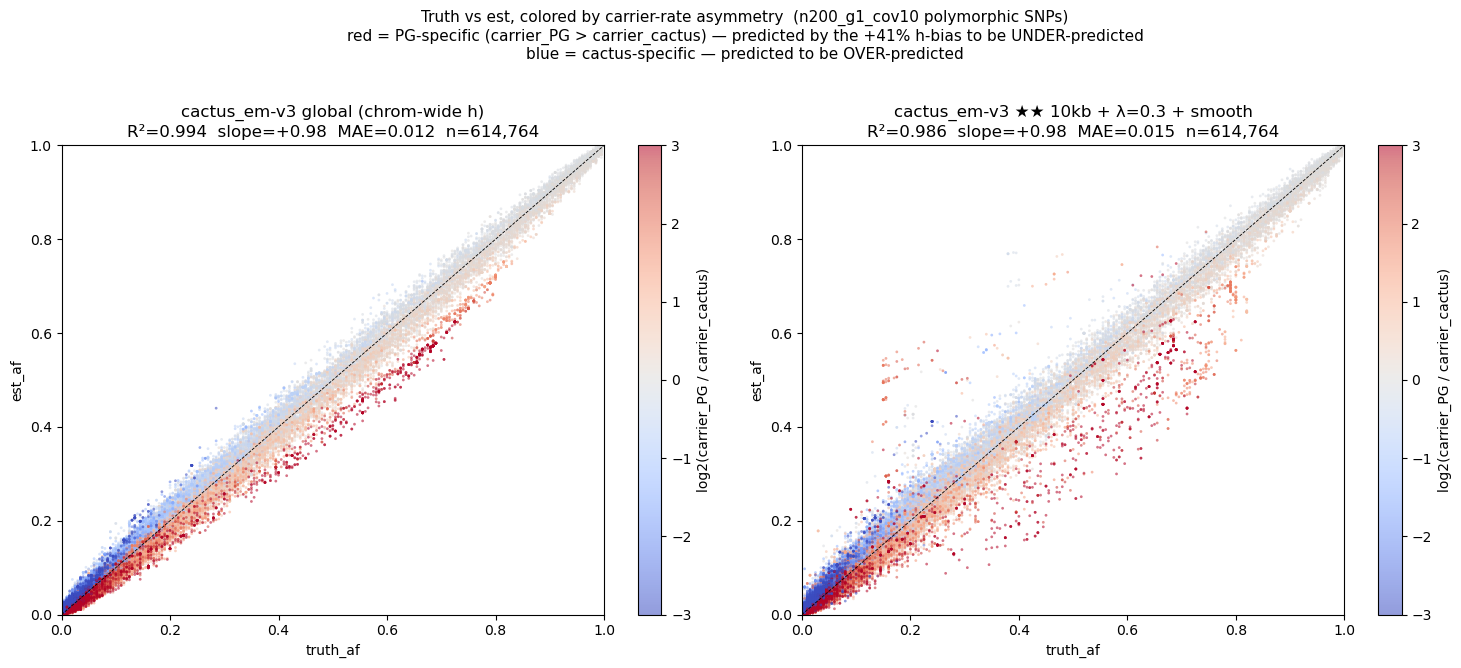

In [4]:
N_PLOT = 100_000  # subsample for legibility

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

for ax, (key, (label, _)) in zip(axes, METHODS.items()):
    sub = snps.dropna(subset=[key])
    if len(sub) > N_PLOT:
        plot_sub = sub.sample(N_PLOT, random_state=42)
    else:
        plot_sub = sub
    plot_sub = plot_sub.sort_values('log2_pg_cactus', key=np.abs)
    resid = sub[key] - sub.truth_af

    sc = ax.scatter(plot_sub.truth_af, plot_sub[key],
                    c=plot_sub.log2_pg_cactus,
                    cmap='coolwarm', vmin=-3, vmax=3,
                    s=4, alpha=0.55, rasterized=True, edgecolors='none')
    ax.plot([0,1],[0,1],'k--',lw=0.6)
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.set_xlabel('truth_af')
    ax.set_ylabel(f'est_af')
    # R^2 / slope / MAE on the FULL polymorphic SNPs for this method
    r = np.corrcoef(sub.truth_af, sub[key])[0,1]
    slope = np.polyfit(sub.truth_af, sub[key], 1)[0]
    mae = np.mean(np.abs(resid))
    ax.set_title(f'{label}\n'
                 f'R²={r*r:.3f}  slope={slope:+.2f}  MAE={mae:.3f}  n={len(sub):,}')
    cb = plt.colorbar(sc, ax=ax)
    cb.set_label('log2(carrier_PG / carrier_cactus)')

fig.suptitle(f'Truth vs est, colored by carrier-rate asymmetry  ({REGIME} polymorphic SNPs)\n'
             f'red = PG-specific (carrier_PG > carrier_cactus) — predicted by the +41% h-bias to be UNDER-predicted\n'
             f'blue = cactus-specific — predicted to be OVER-predicted',
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()


## 4. Mean residual binned by asymmetry — quantitative bias gradient

If the +41% h-bias mechanism is right, the bias should be a **monotone function** of the asymmetry: more PG-specific → more negative residual (under-prediction), more cactus-specific → more positive residual (over-prediction). The balanced bin (log2 ≈ 0) should sit at residual ≈ 0.


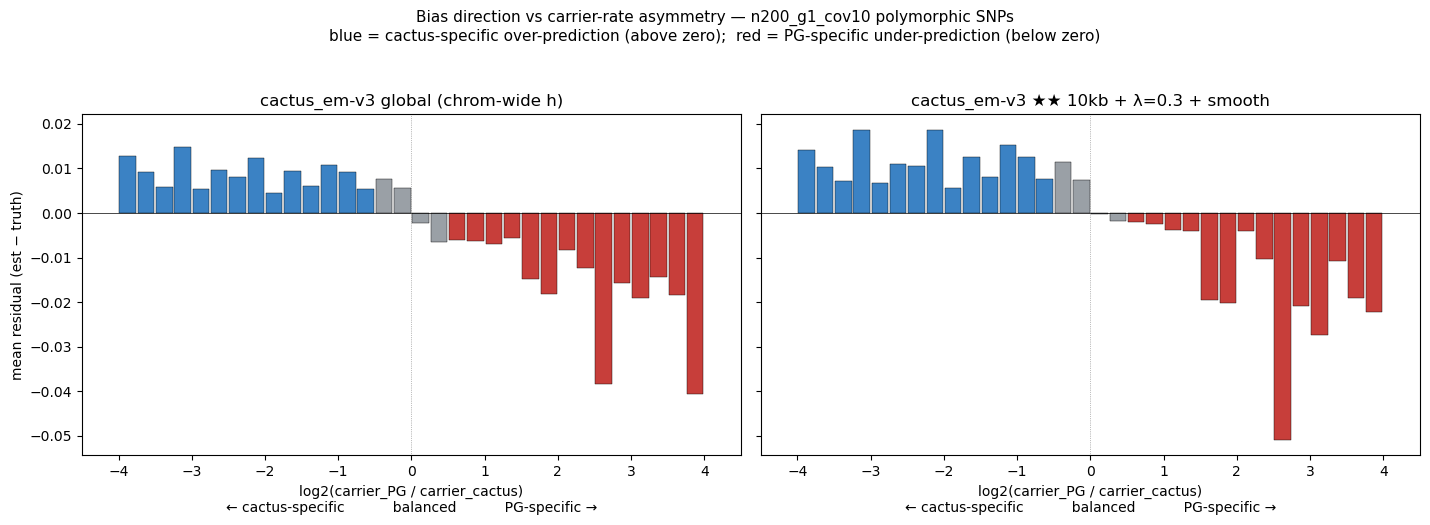

In [5]:
bins = np.linspace(-4, 4, 33)
mid  = 0.5 * (bins[:-1] + bins[1:])
WIDTH = (bins[1] - bins[0]) * 0.9

# Bars colored by bin (cool=cactus-specific, warm=PG-specific) — SAME scheme as the scatter.
# Method distinction is done by SUBPLOT, not by color.
def bar_color(x):
    if x < -0.5: return '#3b82c4'   # blue  — cactus-specific
    if x >  0.5: return '#c73e3a'   # red   — PG-specific
    return '#9aa0a6'                 # gray  — balanced

fig, axes = plt.subplots(1, len(METHODS), figsize=(7.2 * len(METHODS), 5.0), sharey=True)
if len(METHODS) == 1:
    axes = [axes]

for ax, (key, (label, _)) in zip(axes, METHODS.items()):
    sub = snps.dropna(subset=[key]).copy()
    sub['residual'] = sub[key] - sub.truth_af
    mean_resid = []
    n_per_bin  = []
    for i in range(len(bins) - 1):
        m = (sub.log2_pg_cactus >= bins[i]) & (sub.log2_pg_cactus < bins[i+1])
        n_per_bin.append(int(m.sum()))
        mean_resid.append(sub.loc[m, 'residual'].mean() if m.sum() >= 10 else np.nan)

    colors = [bar_color(x) for x in mid]
    ax.bar(mid, mean_resid, width=WIDTH, color=colors,
           edgecolor='black', linewidth=0.3)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('log2(carrier_PG / carrier_cactus)\n'
                  '← cactus-specific           balanced           PG-specific →')
    ax.set_title(label)
    ax.set_xlim(-4.5, 4.5)

axes[0].set_ylabel('mean residual (est − truth)')
fig.suptitle(f'Bias direction vs carrier-rate asymmetry — {REGIME} polymorphic SNPs\n'
             'blue = cactus-specific over-prediction (above zero);  red = PG-specific under-prediction (below zero)',
             y=1.04, fontsize=11)
plt.tight_layout()
plt.show()


## 5. Stratified summary by asymmetry class

Splits SNPs into three classes and reports n, mean truth, mean est, mean residual, and RMSE for each.


In [6]:
def bin_label(x):
    if x < -2: return '1. cactus-specific (log2 < -2)'
    if x > 2:  return '3. PG-specific     (log2 > +2)'
    return     '2. balanced        (|log2| <= 2)'

snps_lbl = snps.assign(asym_class=snps.log2_pg_cactus.apply(bin_label))

print(f'=== {REGIME} polymorphic SNPs — stratified by carrier-rate asymmetry ===\n')
all_stats = {}
for key, (label, _) in METHODS.items():
    sub = snps_lbl.dropna(subset=[key]).copy()
    sub['residual'] = sub[key] - sub.truth_af
    stats = sub.groupby('asym_class').agg(
        n_variants=('truth_af','size'),
        mean_truth=('truth_af','mean'),
        mean_est=(key,'mean'),
        mean_residual=('residual','mean'),
        rmse=('residual', lambda x: float(np.sqrt(np.mean(x**2)))),
    ).round(4)
    stats['pct_of_snps'] = (100 * stats.n_variants / len(sub)).round(2)
    stats = stats[['n_variants','pct_of_snps','mean_truth','mean_est','mean_residual','rmse']]
    print(f'### {label}')
    print(stats.to_string())
    print()
    all_stats[key] = stats

# Side-by-side residual comparison: same-class deltas between global and window
print('=== Δ (window − global) on mean residual per class ===\n')
delta = (all_stats['window']['mean_residual'] - all_stats['global']['mean_residual']).round(4)
print(delta.to_string())
print('\nInterpret: similar magnitudes = bias is structural in h (not window-specific).')
print('If ★★ has notably larger |residual| than global, per-window noise is amplifying the bias.')


=== n200_g1_cov10 polymorphic SNPs — stratified by carrier-rate asymmetry ===



### cactus_em-v3 global (chrom-wide h)
                                  n_variants  pct_of_snps  mean_truth  mean_est  mean_residual    rmse
asym_class                                                                                            
1. cactus-specific (log2 < -2)         37346         6.07      0.0232    0.0312         0.0080  0.0125
2. balanced        (|log2| <= 2)      550242        89.50      0.1626    0.1640         0.0014  0.0164
3. PG-specific     (log2 > +2)         27176         4.42      0.1265    0.1041        -0.0224  0.0421



### cactus_em-v3 ★★ 10kb + λ=0.3 + smooth
                                  n_variants  pct_of_snps  mean_truth  mean_est  mean_residual    rmse
asym_class                                                                                            
1. cactus-specific (log2 < -2)         37346         6.07      0.0232    0.0333         0.0101  0.0182
2. balanced        (|log2| <= 2)      550242        89.50      0.1626    0.1665         0.0039  0.0233
3. PG-specific     (log2 > +2)         27176         4.42      0.1265    0.1029        -0.0236  0.0691

=== Δ (window − global) on mean residual per class ===

asym_class
1. cactus-specific (log2 < -2)      0.0021
2. balanced        (|log2| <= 2)    0.0025
3. PG-specific     (log2 > +2)     -0.0012

Interpret: similar magnitudes = bias is structural in h (not window-specific).
If ★★ has notably larger |residual| than global, per-window noise is amplifying the bias.


## 6. Reading the result

1. **Both panels in cell 3** should show the same blue/red streak pattern: above-diagonal points blue (cactus-specific), below-diagonal points red (PG-specific), main-diagonal cloud gray. If both show it, the bias is **structural to the h-vector** — not a window-mode artifact.

2. **The bar chart in cell 4** should show monotone gradients for both methods: residual increases from negative (PG-specific bins, right) to positive (cactus-specific bins, left). If global shows a smaller gradient than ★★, that's per-window noise amplifying the underlying bias.

3. **The stratified tables in cell 5** quantify the per-class bias. The `mean_residual` column should be ≈ 0 in the balanced class, positive in cactus-specific, negative in PG-specific.

If all three confirm: the +41% cactus h-bias mechanism is the cause of both off-diagonal streaks. The production fix is the **80-founder control + Beagle-imputed cn_full rebuild** path documented in `HANDOFF_80FOUNDER_CONTROL.md`.

To re-run on another regime, edit the `REGIME` variable in cell 2 and re-execute cells 4 onward.
